In [146]:
def add(a:int,b:int)->int:
    return a+b

In [147]:
add(5,4)

9

In [148]:
add(5.2,4)

9.2

In [149]:
from ensure import ensure_annotations

In [150]:
@ensure_annotations
def add1(a:int,b:int)->int:
    return a+b

In [151]:
#add(3.2,4)

In [152]:
def mul(a:int,b:int)->int:
    return a*b

In [153]:
mul(4,5)

20

In [154]:
from typing_extensions import TypedDict

In [155]:
from langgraph.graph import START, END

In [156]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [157]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [158]:
from langchain_groq import ChatGroq

In [159]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [160]:
llm.invoke("Hey").content

'Hey there! 👋 How can I help you today?'

In [161]:
llm_tool=llm.bind_tools([add,mul])

In [162]:
result=llm_tool.invoke("multiply 2 and 4")

In [163]:
result.tool_calls

[{'name': 'mul',
  'args': {'a': 2, 'b': 4},
  'id': 'fc_cc395216-836b-4df2-a2c3-62e4c5cc3cd7',
  'type': 'tool_call'}]

In [164]:
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, END, StateGraph

In [165]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [166]:
def llm_output(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [167]:
from langgraph.graph import StateGraph
builder=StateGraph(State)
builder.add_node("CHatBot",llm_output)
builder.add_node("add_tool",add)
builder.add_node("multiply_tool",mul)

builder.add_edge(START,"CHatBot")
builder.add_edge("CHatBot",END)

graph=builder.compile()



In [168]:
from IPython.display import display, Image

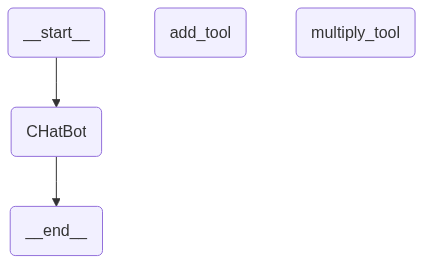

In [169]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [170]:
graph.invoke({"messages":"hey"})

{'messages': [HumanMessage(content='hey', additional_kwargs={}, response_metadata={}, id='805f79ae-c461-4e40-8c5d-ba86478e17b3'),
  AIMessage(content='Hey there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hey". Probably a greeting. We should respond politely. Probably ask how can help.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 72, 'total_tokens': 115, 'completion_time': 0.044257533, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.003844113, 'prompt_tokens_details': None, 'queue_time': 0.281041576, 'total_time': 0.048101646}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_fcc9b7b2df', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02f18-db81-7f23-8969-7d6b1ce7411a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 43, 'total_tokens': 115, 'output_token_details

In [171]:
from langchain_core.messages import HumanMessage, AIMessage

In [174]:
messages=graph.invoke({"messages":HumanMessage(content="What is 2 multiply 3")})

In [193]:
messages["messages"][-1].content

'2 multiplied by 3 equals **6**.'

In [189]:
State["messages"]

__main__.State['messages']

In [192]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [HumanMessage(content="What is AI?")]
})

print(result["messages"][-1].content)

**Artificial Intelligence (AI)** is a branch of computer science that creates systems capable of performing tasks that normally require human intelligence. These tasks include:

| Task | Typical Human Skill | AI Approach |
|------|---------------------|-------------|
| Recognizing speech | Hearing & interpreting | Speech‑to‑text models |
| Understanding language | Reading & reasoning | Natural‑Language Processing (NLP) |
| Seeing objects | Visual perception | Computer vision / image recognition |
| Making decisions | Logic & judgment | Machine learning, rule‑based systems |
| Learning from experience | Adaptation | Reinforcement learning, neural networks |

### Core Ideas
1. **Representation** – How knowledge is stored (e.g., rules, data, neural weights).
2. **Reasoning** – How the system processes information to reach conclusions (e.g., inference engines, probabilistic models).
3. **Learning** – How the system improves over time (e.g., supervised, unsupervised, reinforcement learning)

In [194]:
def llm_tool_output(state:State):
    return {"messages":[llm_tool.invoke(state["messages"])]}

In [208]:
from langgraph.graph import StateGraph
builder=StateGraph(State)
builder.add_node("CHatBot",llm_tool_output)


builder.add_edge(START,"CHatBot")


builder.add_edge("CHatBot",END)

graph=builder.compile()


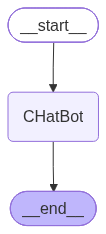

In [209]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [210]:
result=graph.invoke({"messages":HumanMessage(content="Hey")})

In [211]:
result["messages"][-1].content

'Hey there! How can I help you today?'

In [212]:
result=graph.invoke({"messages":HumanMessage(content="multiply 2 and 4")})

In [213]:
result

{'messages': [HumanMessage(content='multiply 2 and 4', additional_kwargs={}, response_metadata={}, id='0039ff7f-61d2-4f3c-99c9-c28ae4b8d5da'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to use the mul function.', 'tool_calls': [{'id': 'fc_7f77c627-d4f4-4e35-8319-49317df247f5', 'function': {'arguments': '{"a":2,"b":4}', 'name': 'mul'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 140, 'total_tokens': 175, 'completion_time': 0.036121791, 'completion_tokens_details': {'reasoning_tokens': 9}, 'prompt_time': 0.006747642, 'prompt_tokens_details': None, 'queue_time': 0.284902697, 'total_time': 0.042869433}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3cdd24b83b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02f2c-1d80-7af1-9804-31fbfa14f59c-0', tool_calls=[{'name': 'mul', 'args': {'a': 2, 'b': 4}, 'id': 'fc_7f77c627-d